This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction

In [146]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [147]:
import warnings
warnings.filterwarnings("ignore")

In [148]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "AAPL"
df_HKstock = yf.download(company, start="2019-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436928,37.657398,36.562166,36.718628,148158800
2019-01-03,33.707928,34.544758,33.662885,34.132268,365248800
2019-01-04,35.146900,35.215650,34.089603,34.262658,234428400
2019-01-07,35.068665,35.282023,34.587428,35.251204,219111200
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200


In [149]:
# Save copy to CSV
df_HKstock.to_csv('AAPL260101.csv')

In [150]:
#
df_source = pd.read_csv("AAPL260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.436928,37.657398,36.562166,36.718628,148158800
1,2019-01-03,33.707928,34.544758,33.662885,34.132268,365248800
2,2019-01-04,35.146900,35.215650,34.089603,34.262658,234428400
3,2019-01-07,35.068665,35.282023,34.587428,35.251204,219111200
4,2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...,...
1755,2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
1756,2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800
1757,2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200
1758,2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600


In [151]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.436928,37.657398,36.562166,36.718628,148158800
1,2019-01-03,33.707928,34.544758,33.662885,34.132268,365248800
2,2019-01-04,35.146900,35.215650,34.089603,34.262658,234428400
3,2019-01-07,35.068665,35.282023,34.587428,35.251204,219111200
4,2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...,...
1755,2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
1756,2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800
1757,2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200
1758,2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600


In [152]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1760 non-null   datetime64[ns]
 1   Close   1760 non-null   float64       
 2   High    1760 non-null   float64       
 3   Low     1760 non-null   float64       
 4   Open    1760 non-null   float64       
 5   Volume  1760 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 82.6 KB


In [153]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1760 entries, 2019-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1760 non-null   float64
 1   High    1760 non-null   float64
 2   Low     1760 non-null   float64
 3   Open    1760 non-null   float64
 4   Volume  1760 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB


In [154]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436928,37.657398,36.562166,36.718628,148158800
2019-01-03,33.707928,34.544758,33.662885,34.132268,365248800
2019-01-04,35.146900,35.215650,34.089603,34.262658,234428400
2019-01-07,35.068665,35.282023,34.587428,35.251204,219111200
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200


In [155]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [156]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436928,37.657398,36.562166,36.718628,148158800
2019-01-03,33.707928,34.544758,33.662885,34.132268,365248800
2019-01-04,35.146900,35.215650,34.089603,34.262658,234428400
2019-01-07,35.068665,35.282023,34.587428,35.251204,219111200
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200


In [157]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [158]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2019-01-02,37.436928,37.657398,36.562166,36.718628,148158800,NaN,NaN,NaN
2019-01-03,33.707928,34.544758,33.662885,34.132268,365248800,NaN,NaN,-0.099608
2019-01-04,35.146900,35.215650,34.089603,34.262658,234428400,NaN,NaN,0.042689
2019-01-07,35.068665,35.282023,34.587428,35.251204,219111200,NaN,NaN,-0.002226
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200,NaN,NaN,0.019063
2019-01-09,36.344059,36.633276,35.471671,35.865192,180396400,NaN,NaN,0.016982
2019-01-10,36.460224,36.500524,35.763260,36.152042,143122800,NaN,NaN,0.003196
2019-01-11,36.102249,36.436508,35.917341,36.242119,108092800,NaN,NaN,-0.009818
2019-01-14,35.559380,35.860450,35.374471,35.760884,129756800,NaN,NaN,-0.015037


In [159]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2019-03-14,43.742294,43.830386,43.463742,43.782767,94318000,41.620062,39.303857,0.011116
2019-03-15,44.311314,44.599391,43.744687,44.008956,156171600,41.802431,39.441345,0.013008
2019-03-18,44.763660,44.851749,44.232741,44.235124,104879200,42.011941,39.662459,0.010208
2019-03-19,44.408920,44.994597,44.263692,44.842226,126585600,42.197643,39.847700,-0.007925
2019-03-20,44.796997,45.113643,43.980383,44.337502,124140800,42.389654,40.042266,0.008739
...,...,...,...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600,276.399652,270.219041,0.005324
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800,276.192715,270.703751,-0.001497
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,275.938907,271.233303,0.001317


In [160]:
# Configuration

# For ~ 80:20 Split
test_days = 350

# choose the number of days on which to base our predictions 
nb_days = 60

# Number of days into the future we want to predict
n_steps_out = 30


In [161]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [162]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -0.7784770398702142
p-value: 0.8253626706601023
The series is not stationary.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

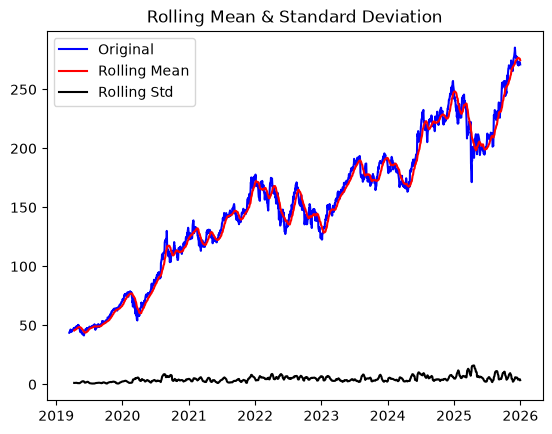

Results of Dickey-Fuller Test:
Test Statistic                   -0.778477
p-value                           0.825363
#Lags Used                        0.000000
Number of Observations Used    1710.000000
Critical Value (1%)              -3.434180
Critical Value (5%)              -2.863232
Critical Value (10%)             -2.567671
dtype: float64


In [163]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

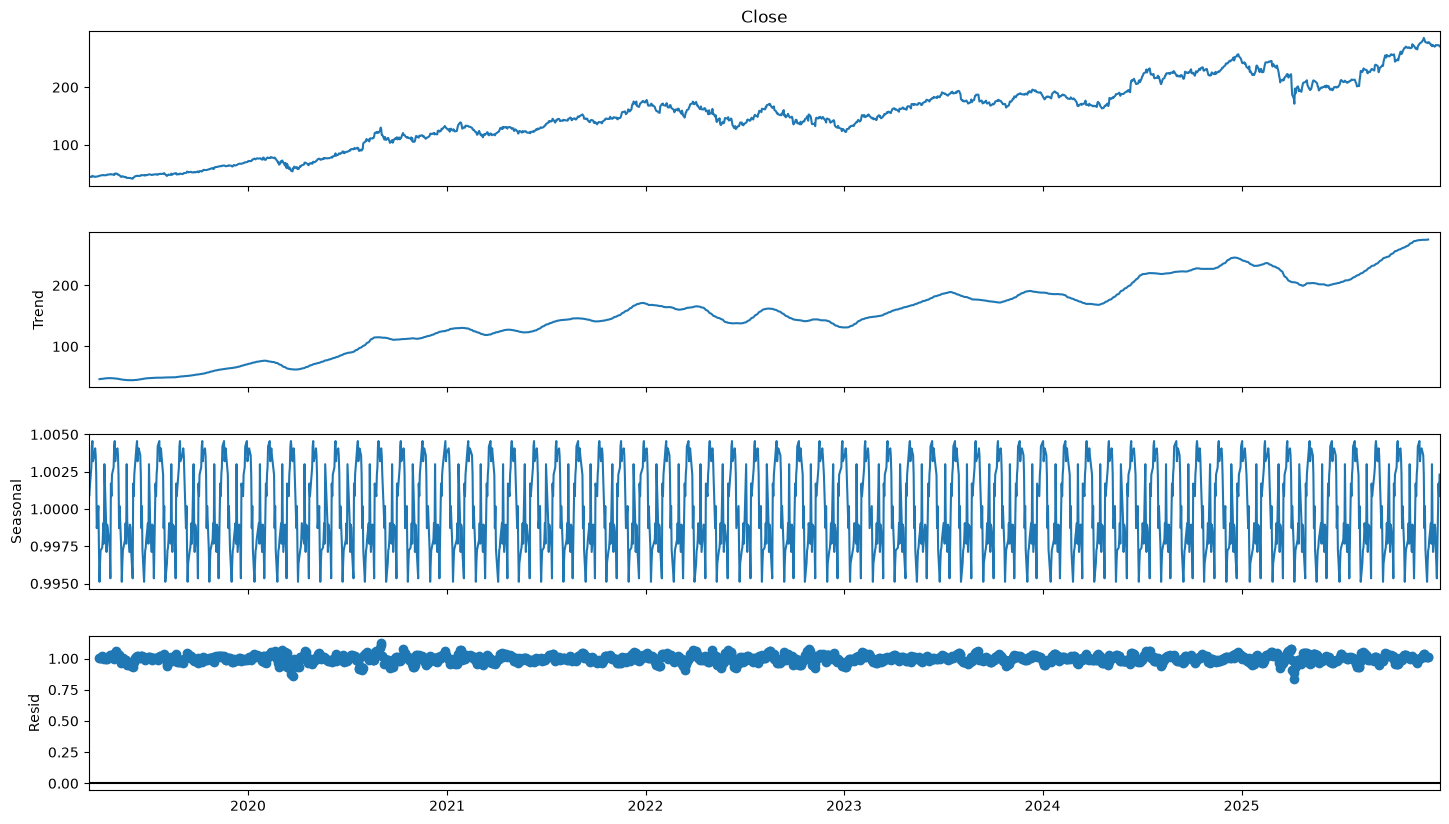

In [164]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

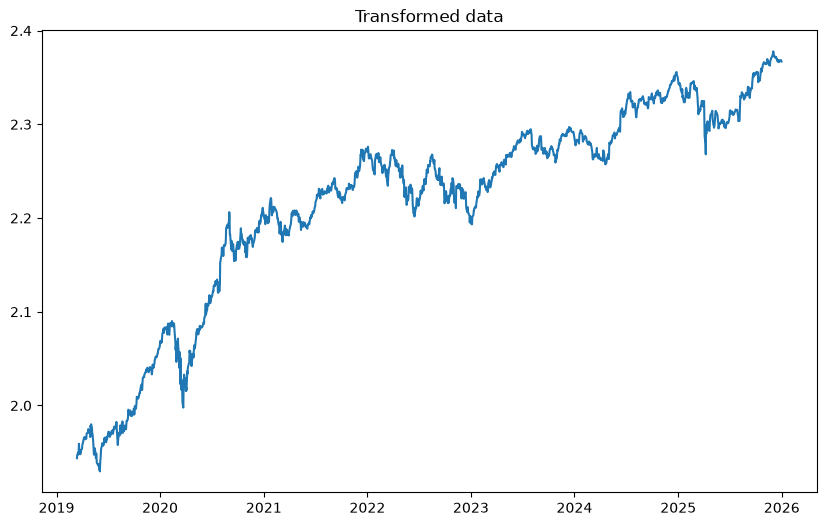

In [165]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

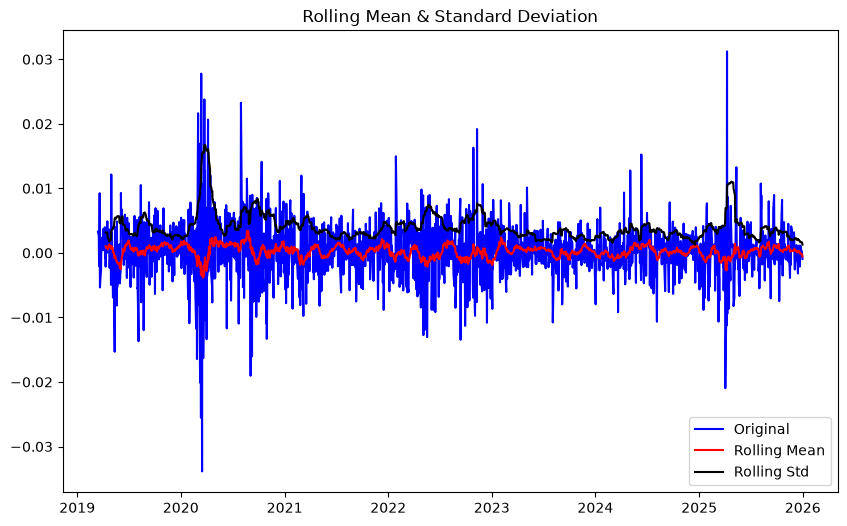

Results of Dickey-Fuller Test:
Test Statistic                -1.324008e+01
p-value                        9.209077e-25
#Lags Used                     9.000000e+00
Number of Observations Used    1.700000e+03
Critical Value (1%)           -3.434202e+00
Critical Value (5%)           -2.863242e+00
Critical Value (10%)          -2.567676e+00
dtype: float64


In [166]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [167]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
#nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

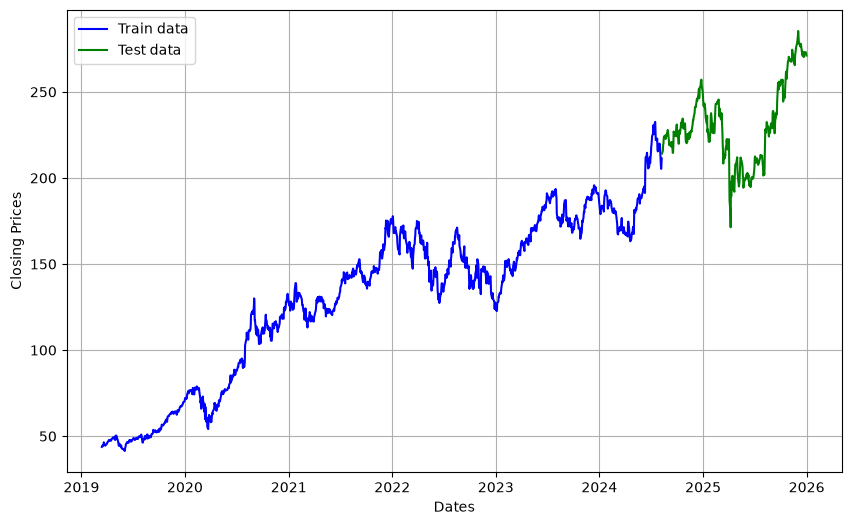

In [168]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [169]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [170]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 3.3286e-05 - mean_absolute_error: 0.0043
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 2.1807e-05 - mean_absolute_error: 0.0033
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.1683e-05 - mean_absolute_error: 0.0033
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.2052e-05 - mean_absolute_error: 0.0034
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.2811e-05 - mean_absolute_error: 0.0034
Epoch 6/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 2.1731e-05 - mean_absolute_error: 0.0033
Epoch 7/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 2.3296e-05 - mean_absolute_error: 0.0035
Epoch 8/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 2.3144e-05 - mean_absolute_error: 0.0035
Epoch 9/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 2.1515e-05 - mean_absolute_error: 0.0033
Epoch 10/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 2.1556e-05 - mean_absolute_error: 0.0033

In [171]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.5931e-05 - mean_absolute_error: 0.0025
Test MSE: 1.593117121956311e-05
Test MAE: 0.0025344134774059057


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


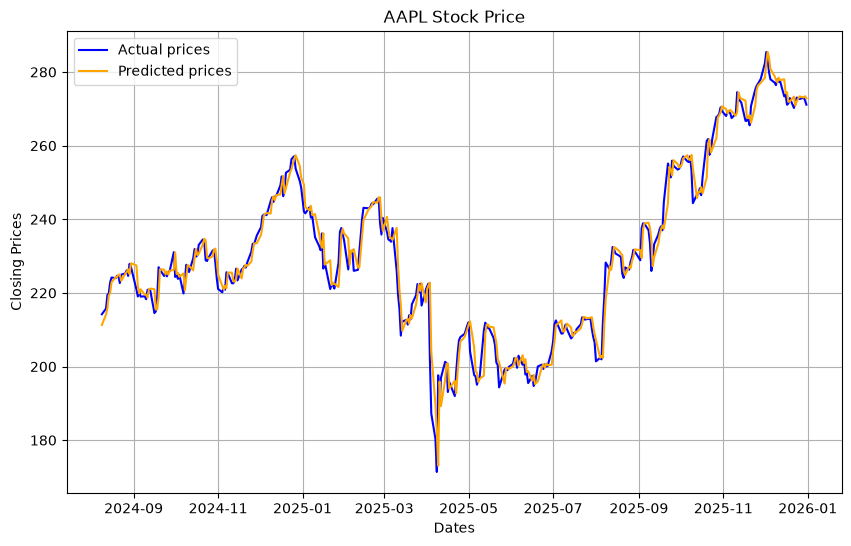

In [172]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

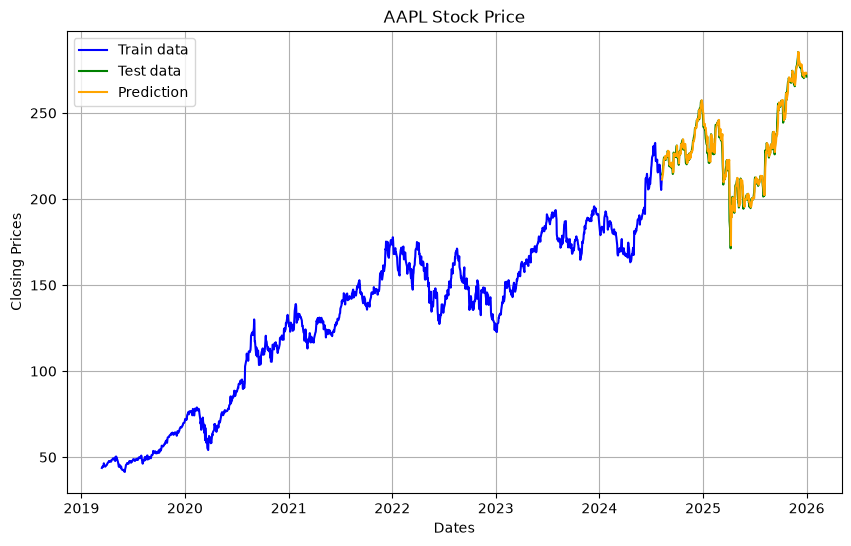

In [173]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [174]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
#n_steps_out = 30

# choose the number of days on which to base our predictions 
#nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [175]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 30)                  │           1,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,930 (46.60 KB)

 Trainable params: 11,930 (46.60 KB)

 Non-trainable params: 0 (0.00 B)

In [176]:
#...
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 2.2853e-05 - mean_absolute_error: 0.0034
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 2.2173e-05 - mean_absolute_error: 0.0033
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 2.2317e-05 - mean_absolute_error: 0.0033
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.2384e-05 - mean_absolute_error: 0.0033
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 2.2178e-05 - mean_absolute_error: 0.0033
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 2.2183e-05 - mean_absolute_error: 0.0033
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 2.2113e-05 - mean_absolute_error: 0.0033
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 2.2209e-05 - mean_absolute_error: 0.0033
Epoch 9/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 2.2115e-05 - mean_absolute_error: 0.0033
Epoch 10/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 2.2123e-05 - mean_absolute_error: 0.0033

In [177]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.6474e-05 - mean_absolute_error: 0.0027
Test MSE: 1.6474023141199723e-05
Test MAE: 0.002652272116392851


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


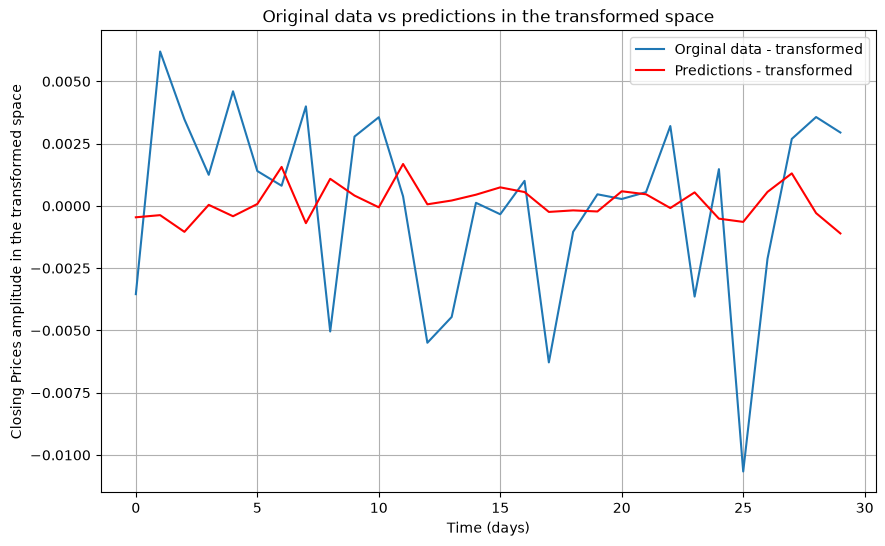

In [178]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [179]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2024-08-09    2.322997
2024-08-12    2.322625
2024-08-13    2.321584
2024-08-14    2.321626
2024-08-15    2.321211
2024-08-16    2.321287
2024-08-19    2.322853
2024-08-20    2.322160
2024-08-21    2.323247
2024-08-22    2.323662
2024-08-23    2.323605
2024-08-26    2.325288
2024-08-27    2.325351
2024-08-28    2.325568
2024-08-29    2.326018
2024-08-30    2.326763
2024-09-03    2.327319
2024-09-04    2.327077
2024-09-05    2.326897
2024-09-06    2.326673
2024-09-09    2.327260
2024-09-10    2.327726
2024-09-11    2.327640
2024-09-12    2.328183
2024-09-13    2.327671
2024-09-16    2.327029
2024-09-17    2.327591
2024-09-18    2.328896
2024-09-19    2.328607
2024-09-20    2.327502
dtype: float64


In [180]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2024-08-09    220.591622
2024-08-12    220.211664
2024-08-13    219.149372
2024-08-14    219.192056
2024-08-15    218.770011
2024-08-16    218.847524
2024-08-19    220.444179
2024-08-20    219.735667
2024-08-21    220.848008
2024-08-22    221.274450
2024-08-23    221.216092
2024-08-26    222.953251
2024-08-27    223.019489
2024-08-28    223.244388
2024-08-29    223.712291
2024-08-30    224.488540
2024-09-03    225.070263
2024-09-04    224.817150
2024-09-05    224.628856
2024-09-06    224.394955
2024-09-09    225.008778
2024-09-10    225.497653
2024-09-11    225.407006
2024-09-12    225.977593
2024-09-13    225.439361
2024-09-16    224.766825
2024-09-17    225.355464
2024-09-18    226.729689
2024-09-19    226.424052
2024-09-20    225.262527
dtype: float64


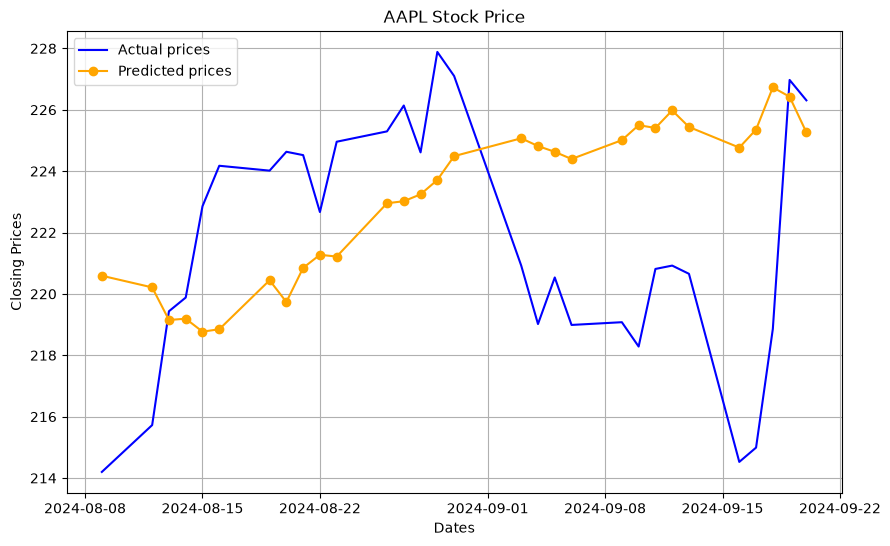

In [181]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [182]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Extract the exact actual prices that align with the prediction period
# Based on your plot, 'pred' starts at 'the_day' and goes forward for 'n_steps_out' steps.
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

# 2. Ensure both are flattened 1D arrays/Series with no missing values
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.029
Method:                 Least Squares   F-statistic:                    0.1953
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.662
Time:                        19:59:01   Log-Likelihood:                -70.237
No. Observations:                  30   AIC:                             144.5
Df Residuals:                      28   BIC:                             147.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        235.2275     27.486      8.558      0.0

In [183]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Replace these arrays with your actual test data and model predictions
# Example: y_true (actual market prices), y_pred (your LSTM or ARIMA predictions)
#y_true = np.array([100.0, 102.5, 101.2, 105.0, 107.8])
#y_pred = np.array([101.2, 101.0, 102.0, 104.5, 109.1])

# 2. Calculate Standard Regression Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# 3. Calculate Directional Accuracy (Crucial for price trends)
# Compares if the predicted direction (up/down) matches the actual direction
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

# 4. Print Evaluation Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"R² Score (Goodness of Fit):     {r2:.4f}")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      4.3083
Mean Squared Error (MSE):       24.7780
Root Mean Squared Error (RMSE): 4.9777
Mean Absolute Pct Error (MAPE): 1.96%
R² Score (Goodness of Fit):     -0.6863
Directional Accuracy (DA):      48.28%


In [135]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [136]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [137]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [131]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=30, batch_size=32)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0374
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4736e-04
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5660e-04
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.3163e-04
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.0921e-04
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9005e-04
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7026e-04
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.5592e-04
Epoch 10/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4520e-04
Epoch 11/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4557e-04
Epoch 12/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.1931e-04
Epoch 13/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.1435e-04
Epoch 14/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.2458e-04
Epoch 15/30
42/42 ━━━━━

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [138]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=30, batch_size=32)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0211
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0022
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0019
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0019
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0016
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0016
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0014
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0014
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0013
Epoch 10/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0014
Epoch 11/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0011
Epoch 12/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0010
Epoch 13/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0011
Epoch 14/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.5409e-04
Epoch 15/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 9.6987e

In [139]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


In [140]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.032629708065400956


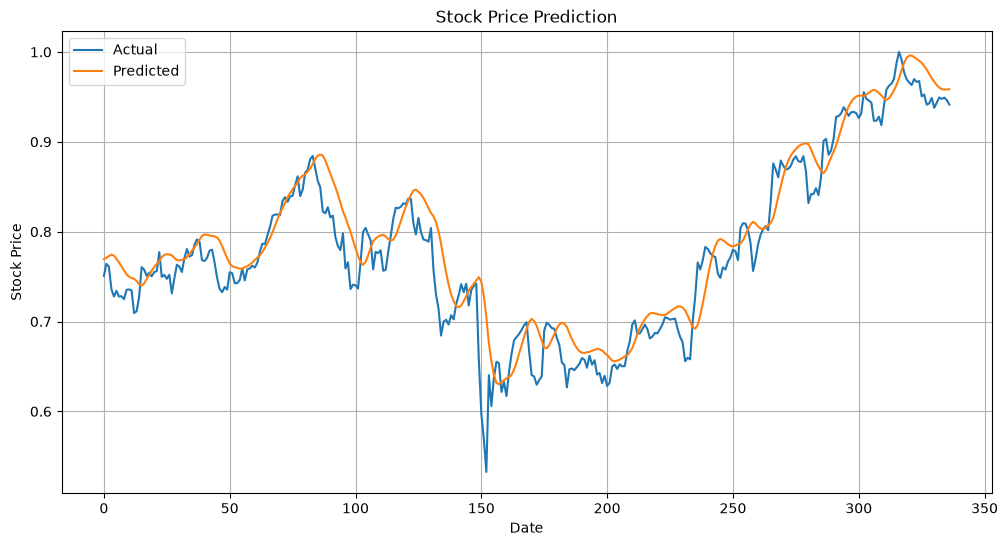

In [141]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.